In [1]:
!pip install kagglehub opencv-python scikit-learn

In [2]:
import kagglehub
import os
import re
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print("Descargando dataset...")
path = kagglehub.dataset_download("aryashah2k/highway-traffic-videos-dataset")
print("Ruta del dataset:", path)

c:\todo\Anaconda\envs\curso_ia\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Descargando dataset...
Ruta del dataset: C:\Users\alere\.cache\kagglehub\datasets\aryashah2k\highway-traffic-videos-dataset\versions\1


In [3]:
import os
import cv2
import numpy as np

video_dir = os.path.join(path, 'video')

# 1. Configuration for extracting frames
IMG_SIZE = (64, 64)
MAX_FRAMES = 20
videos = []
labels = []

print("Extracting videos and generating synthetic labels...")

# 2. Get a sorted list of all valid video files
video_files = [f for f in os.listdir(video_dir) if f.endswith(('.mp4', '.avi', '.mov'))]
video_files.sort()

# Calculate the chunk size to split the videos into 3 artificial classes
total_videos = len(video_files)
chunk_size = total_videos // 3

# 3. Process each video and assign it to Class 0, 1, or 2 based on its position
for idx, file_name in enumerate(video_files):
    video_path = os.path.join(video_dir, file_name)
    
    # Determine synthetic class (0, 1, or 2)
    if idx < chunk_size:
        synthetic_label = 0
    elif idx < chunk_size * 2:
        synthetic_label = 1
    else:
        synthetic_label = 2
        
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, IMG_SIZE)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = frame / 255.0
        frames.append(frame)
        if len(frames) == MAX_FRAMES:
            break
    cap.release()
    
    # Pad with zeros if the video is too short
    while len(frames) < MAX_FRAMES:
        frames.append(np.zeros((IMG_SIZE[1], IMG_SIZE[0], 3)))
        
    videos.append(np.array(frames))
    labels.append(synthetic_label)

X = np.array(videos)
y = np.array(labels)

print("Extraction complete.")
print("X shape (Samples, Frames, Width, Height, Channels):", X.shape)
print("y shape (Labels):", y.shape)
print("Unique synthetic classes created:", np.unique(y))

Extracting videos and generating synthetic labels...
Extraction complete.
X shape (Samples, Frames, Width, Height, Channels): (254, 20, 64, 64, 3)
y shape (Labels): (254,)
Unique synthetic classes created: [0 1 2]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Muestras de entrenamiento:", len(X_train))
print("Muestras de prueba:", len(X_test))

Muestras de entrenamiento: 203
Muestras de prueba: 51


In [5]:
model = Sequential()

# CNN (Extracción de características espaciales de cada frame)
model.add(TimeDistributed(Conv2D(32, (3, 3), activation='relu'), input_shape=(MAX_FRAMES, IMG_SIZE[0], IMG_SIZE[1], 3)))
model.add(TimeDistributed(MaxPooling2D((2, 2))))
model.add(TimeDistributed(Conv2D(64, (3, 3), activation='relu')))
model.add(TimeDistributed(MaxPooling2D((2, 2))))
model.add(TimeDistributed(Flatten()))

# RNN (Análisis temporal del movimiento)
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.5))

# Salida de clasificación (3 Clases: Light, Medium, Heavy Traffic)
model.add(Dense(3, activation='softmax'))

model.summary()

c:\todo\Anaconda\envs\curso_ia\lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 20, 62, 62, 32) │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 31, 31, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 20, 29, 29, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 20, 14, 14, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 20, 12544)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │     3,227,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,247,491 (12.39 MB)

 Trainable params: 3,247,491 (12.39 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

print("Iniciando el entrenamiento del modelo...")
history = model.fit(X_train, y_train, 
                    epochs=20, 
                    batch_size=8, 
                    validation_data=(X_test, y_test))

Iniciando el entrenamiento del modelo...
Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 529ms/step - accuracy: 0.3350 - loss: 1.2260 - val_accuracy: 0.3333 - val_loss: 1.0836
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 437ms/step - accuracy: 0.2759 - loss: 1.1746 - val_accuracy: 0.3333 - val_loss: 1.0899
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 436ms/step - accuracy: 0.3645 - loss: 1.1197 - val_accuracy: 0.3333 - val_loss: 1.0992
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 437ms/step - accuracy: 0.3300 - loss: 1.1262 - val_accuracy: 0.3333 - val_loss: 1.1071
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 436ms/step - accuracy: 0.3793 - loss: 1.1010 - val_accuracy: 0.3333 - val_loss: 1.1085
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 434ms/step - accuracy: 0.3498 - loss: 1.1141 - val_accuracy: 0.2353 - val_loss: 1.1097
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 436ms/step - accuracy: 0.3103 - loss: 1.1272 - val_accuracy: 0.2353 - val_loss: 1.1119
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 432ms/step - a

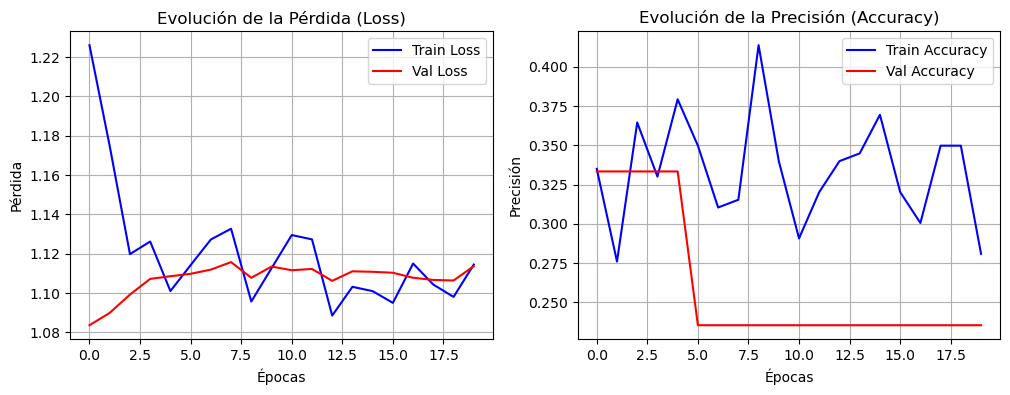

: 

In [ ]:
plt.figure(figsize=(12, 4))

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='red')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='red')
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.show()